In [1]:
import pandas as pd

In [2]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

In [3]:
data = {
    "Study_Hours": [1, 2, 2, 3, 3, 4, 4, 5, 5, 6, 6, 7, 7, 8, 8, 9],
    "Attendance": [45, 50, 55, 60, 65, 55, 70, 60, 75, 65, 80, 70, 85, 75, 90, 95],
    "Result": [
        "Fail", "Fail", "Fail", "Fail",
        "Pass", "Fail", "Pass", "Pass",
        "Pass", "Pass", "Pass", "Pass",
        "Pass", "Pass", "Pass", "Pass"
    ]
}

df = pd.DataFrame(data)

print(df)

    Study_Hours  Attendance Result
0             1          45   Fail
1             2          50   Fail
2             2          55   Fail
3             3          60   Fail
4             3          65   Pass
5             4          55   Fail
6             4          70   Pass
7             5          60   Pass
8             5          75   Pass
9             6          65   Pass
10            6          80   Pass
11            7          70   Pass
12            7          85   Pass
13            8          75   Pass
14            8          90   Pass
15            9          95   Pass


In [4]:
X = df[["Study_Hours", "Attendance"]]
y = df["Result"]

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=42
)

In [26]:
model = RandomForestClassifier(
    n_estimators=100,
    bootstrap=True,
    random_state=42,
    max_features=2
)

In [27]:
model.fit(X_train, y_train)

,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",2
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: b

In [28]:
y_pred = model.predict(X_test)

print("Actual:", y_test.values)
print("Predicted:", y_pred)

Actual: <StringArray>
['Fail', 'Fail', 'Fail', 'Pass']
Length: 4, dtype: str
Predicted: ['Fail' 'Fail' 'Fail' 'Pass']


In [29]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 1.0


In [30]:
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Confusion Matrix:
[[3 0]
 [0 1]]


In [31]:
new_student = pd.DataFrame({
    "Study_Hours": [10],
    "Attendance": [50]
})

In [32]:
prediction = model.predict(new_student)

print("Prediction:", prediction)

Prediction: ['Pass']


In [33]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

In [34]:
plt.figure(figsize=(15, 8))

<Figure size 1500x800 with 0 Axes>

<Figure size 1500x800 with 0 Axes>

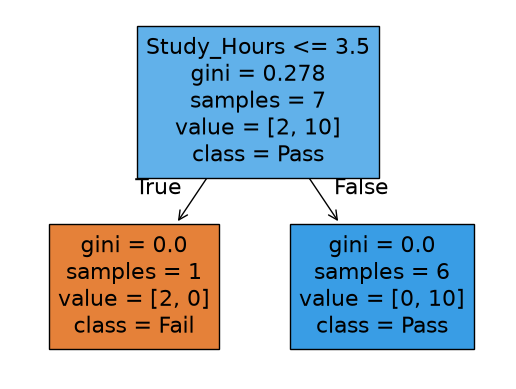

In [35]:
plot_tree(
    model.estimators_[0],
    feature_names=X.columns,
    class_names=model.classes_,
    filled=True
)
plt.show()